# Redes antissociais
### *Como bots com baixo engajamento e alto nível de postagens espalharam fakenews sobre urna eletrônica nas eleições*

Este é um exercício de jornalismo e análise de dados, considerando uma base de 25.659 tweets que eu coletei entre 27 de abril e 2 de outubro de 2022, quando a rede social "X" (ex-Twitter) ainda disponibilizava uma API gratuita que permitia o streaming de postagens.
Coletei tweets especificamente sobre "urna eletrônica", pois minha meta era avaliar a ação de perfis automatizados na disseminação de fakenews envolvendo nossa "pilili" nas polêmicas eleições passadas.
Fiz uma análise de sentimentos, com ajuda da biblioteca "pysentimiento", criada por pesquisadores argentinos. Como ela usa modelos baseados em Transformers (como o BERTweet e o RoBERTuito), ela foi fundamental para analisar o Twitter em espanhol e português durante o período eleitoral - ao contrário de outras populares nativas em inglês.
Após rodar o algoritmo, fiz um refinamento das classificações e criei um dataframe focado apenas nos negativos (45% do total). 
Para conceituar perfil de bot fui bem conservadora: perfis com postagens diárias acima de 100 tweets - considerando somente como suspeitos os que postavam mais de 50 tweets diários. 

Insights gerais sobre a ação dos bots na tentativa de tirar a credibilidade da urna eletrônica:
* Pico de Atividade: forte atuação em maio , mas pico absoluto no mês de junho.
* Muitos posts, poucos seguidores: o gráfico de dispersão, que expõe outllliers, revela que os perfis automatizados possuem poucos engajamentos, mas um volume de tweets por dia estratosférico (chegando a quase 6 mil em alguns casos). É o comportamento clássico de contas criadas apenas para inflar a rede.
* O baixo engajamento dos perfis automáticos indicam que o foco principal deles é enganar os algoritmos de recomendação e colocar os assuntos de uma agenda específica nos top trends - assim como colocar determinados perfis e hashtags entre os mais "falados" do dia inorganicamente. 
* Os Alvos da Rede: Os gráficos mostram que a estratégia dos bots não era aleatória. O maior alvo de respostas (in_reply_to) foi o perfil oficial do TSEjusbr (esforço para minar a credibilidade do órgão), seguido de perto pelo perfil de jairbolsonaro (para gerar engajamento cruzado com a base de apoiadores) e por veículos de imprensa como JovemPanNews.
* Palavras-chave: Os termos mais utilizados nos posts negativos sobre urna eletrônica publicados por perfis automatizados remetem a fakenews, fraude, STF, TSE e Bolsonaro. Porém, fazem também menção a um vídeo (https://t.co/T2UMAJPkug), sobre uma entrevista do Diego Aranha ao Danilo Gentilli no The Noite, em 19/08/2014. No vídeo, o entrevistado relata supostas falhas nas urnas e foi replicado massivamente em 2022.

> 💡 **Curiosidade**
> 
> Para postar 187,3 tweets por dia (média dos bots), uma "pessoa normal" teria de publicar 1 tweet a cada 8 minutos, sem dormir.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")

## Exemplo do dataframe de tweets dos perfis automatizados

In [2]:
df_negativo = pd.read_csv("/home/analab/Documentos/laboratorios/tweets urna eletronica 2022/tweets/tweets_negativos_urna_eletronica_2022_enriquecido.csv")

In [3]:
df_bots = df_negativo.query("tweets_por_dia >= 100.0")

In [4]:
exemplo = df_bots.query("user_screen_name == 'Antonio58123'")
exemplo.head(1)

,tweet_created_at,full_text,retweets,tweet_favorites,in_reply_to,user_name,user_screen_name,user_location,user_description,user_followers_count,...,user_favourites_count,user_verified,user_statuses_count,user_profile_image_url,sentimento,dias_ativos,tweets_por_dia,tipo_usuario,engajamento,follow_back
1456,2022-05-15 11:07:34+00:00,🚨 A urna eletrônica é ilegal e o @TSEjusbr sab...,1.0,2,NaN,Antonio Passos 🇧🇷,Antonio58123,"Rio de Janeiro, Brasil",Eterno é tudo aquilo que pode durar uma fração...,12282.0,...,267925.0,0.0,177264.0,http://pbs.twimg.com/profile_images/1479220725...,negativo,1428.0,124.05,Bot,0.024184,0.995219


## Pico de criação de contas: mais da metade surgiu a partir de 2019

In [5]:
df_bots["user_created_at"] = pd.to_datetime(df_bots["user_created_at"])

df_anos = (
    df_bots["user_created_at"]
    .dt.to_period("Y")
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

df_anos.index = df_anos.index.astype(str)

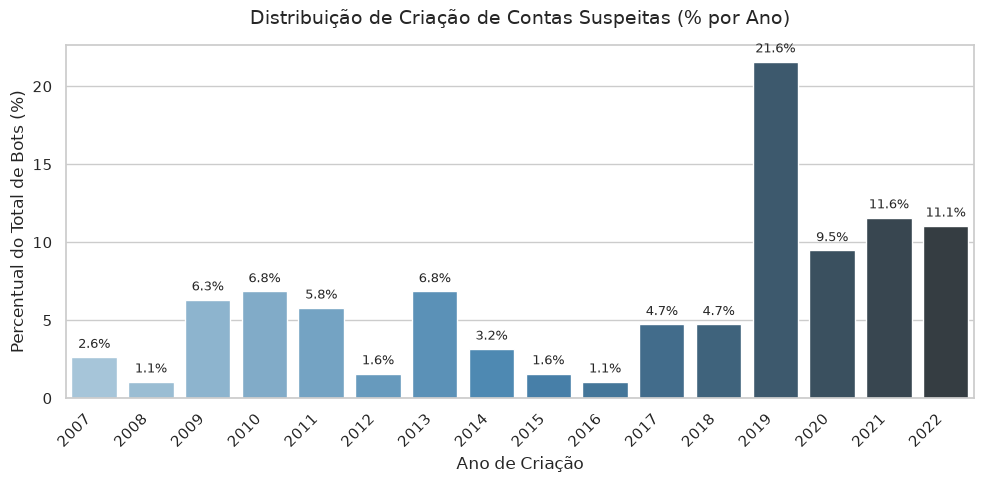

In [6]:
df_meses = (
    df_bots["user_created_at"]
    .dt.to_period("M")
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

df_meses.index = df_meses.index.astype(str)

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=df_anos.index, y=df_anos.values, palette="Blues_d")

plt.title(
    "Distribuição de Criação de Contas Suspeitas (% por Ano)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Ano de Criação", fontsize=12)
plt.ylabel("Percentual do Total de Bots (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Inclina os meses para não encavalar

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Mais da metade (51%) das contas de bots que espalharam tweets negativos sobre a urna eletrônica foram criadas a partir de 2019. Porém, há também muitas contas de mais de uma década.
Isso se explica pelo fato de muitas redes de automação comprarem lotes de contas abandonadas na Deep Web e são reativadas em massa para dar uma falsa sensação de "autoridade" e "organicidade" aos ataques.

## Máquinas de tweets
*Para postar 187,3 tweets por dia, uma 'pessoa normal' teria de publicar 1 tweet a cada 8 minutos, sem dormir!
Tem contas postando bem mais de 200 por dia, inclusive, acendendo um alerta para perfis automatizados e orquestrados*

In [7]:
print("Média de tweets por dia:")
print(df_bots['tweets_por_dia'].mean())

Média de tweets por dia:
187.30362194930905


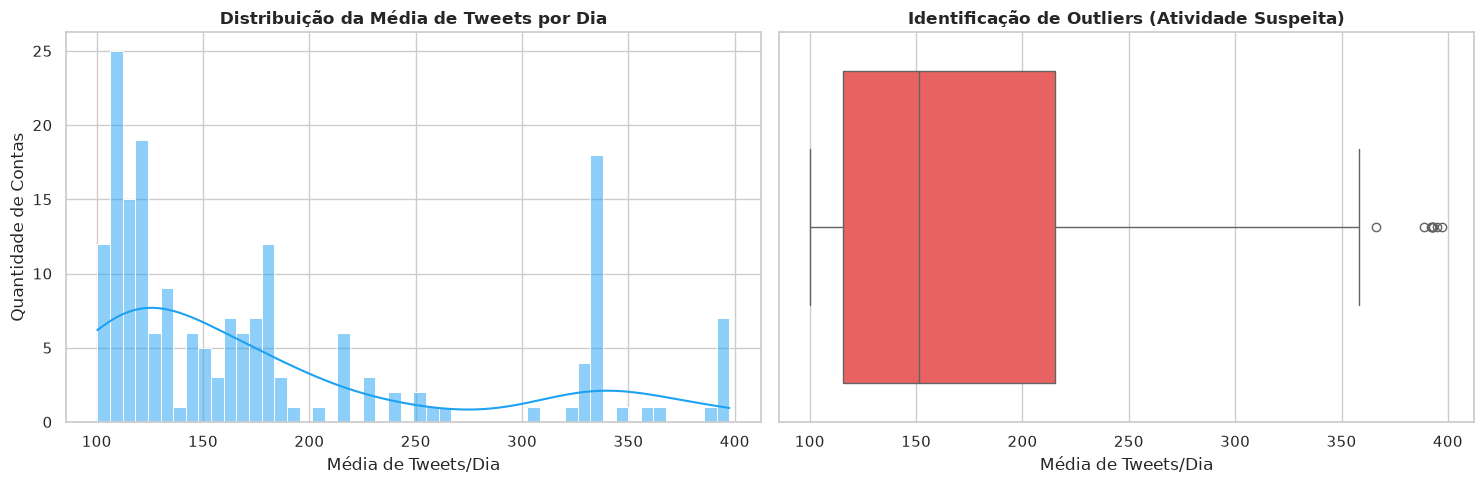

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
df_limpo = df_bots[df_bots["tweets_por_dia"] < 500]

sns.histplot(
    data=df_limpo,
    x="tweets_por_dia",
    bins=50,
    kde=True,
    color="#1DA1F2",
)
plt.title("Distribuição da Média de Tweets por Dia", fontsize=12, fontweight="bold")
plt.xlabel("Média de Tweets/Dia")
plt.ylabel("Quantidade de Contas")

# --- (OUTLIERS) ---
plt.subplot(1, 2, 2)
sns.boxplot(data=df_limpo, x="tweets_por_dia", color="#FF4B4B")
plt.title("Identificação de Outliers (Atividade Suspeita)", fontsize=12, fontweight="bold")
plt.xlabel("Média de Tweets/Dia")

plt.tight_layout()
plt.show()

Para um ser humano manter uma média de 400 tweets por dia durante quase 10 anos seguidos (dias_ativos = 3547), ele precisaria tuitar cerca de 16 tweets por hora, 24 horas por dia, sem dormir, sem comer, sem parar um único dia desde 2013.

A prova matemática definitiva de um robô altamente ativo (Heavy Bot).

Esses dados sugerem que o debate negativo em torno das urnas eletrônicas não foi puramente espontâneo, sendo fortemente inflado e pautado por super-frequentadores artificiais (robôs/heavy bots) operando em escala industrial.

Isso revela a prática do "Astroturfing", a falsa impressão de apoio popular massivo de um tema impulsionado artificialmente por meio de perfis que buscam driblar os algoritmos de recomendação das redes sociais.

## A pauta dos bots
*Urnas não confiáveis, auditoria em papel e fraude foram tópicos difundidos*

In [9]:
print("--- Textos mais repetidos ---")
df_bots["text_clean"] = df_bots["full_text"].str.replace(r'@\w+', '', regex=True)
df_bots["text_clean"] = df_bots["text_clean"].str.strip()
print(df_bots["text_clean"].value_counts().head(10))

--- Textos mais repetidos ---
text_clean
E aí        se este vídeo no qual o especialista afirma que a urna eletrônica pode ser FRAUDADA é "FAKE NEWS", a culpa é do   e não minha.  https://t.co/T2UMAJPkug                                                                                                                                                17
Corno manso é o cidadão que acredita em urna eletrônica não auditável.                                                                                                                                                                                                                                              3
Kassio Nunes Marques derrubou  decisão do TSE sobre a cassação do mandato do deputado estadual do Paraná,por FAKE NEWS sobre urna eletrônica.\nTSE não pode agir assim,como um tribunal de excessão e continuar a ser tolerante com os desmandos da esquerda e implacável com a direita.                            2
a diferença é que nos EUA o v

## Que vídeo é esse?
*O link largamente difundido pelos bots (https://t.co/T2UMAJPkug) remete a uma entrevista, publicada em vídeo no youtube, de Diego Aranha a Danilo Gentili, no The Noite, veiculado originalmente em 19/08/14.
Na entrevista, a fonte defende que a urna possui vulnerabilidades e isso foi utilizado como evidência na rede X de que ela não seria confiável*

## Contas-alvo dos bots
*Contas oficiais do TSE, STF e do ministro Roberto Barroso foram muito mencionadas por bots com tweets negativos sobre a urna, como tentativa de difamação de instâncias oficiais responsáveis pelo sistema eleitoral.
Também buscou-se levar aos top trends perfis como o candidato à reeleição Jair Bolsonaro e Arthur Lira, presidente da Câmara dos Deputados que foi alvo de pressão para impulsionar projeto de auditoria das urnas em papel no Congresso. Para mais contexto histórico, acesse a matéria da BBC: https://www.bbc.com/portuguese/brasil-58124209.
Alexandre remete ao ministro Alexandre de Moraes, que na época era o ministro do Tribunal Superior Eleitoral e virou alvo de ações orquestradas nas redes por defender a lisura o processo eleitoral e a confiabilidade da urna*

In [10]:
mencoes = df_bots["full_text"].str.findall(r"@\w+")
all_mencoes = [j for i in mencoes for j in i]
top_mencoes_pct = (pd.Series(all_mencoes).value_counts(normalize=True) * 100).head(10)
top_formatado = top_mencoes_pct.head(10).map("{:.2f}%".format)
print(top_formatado)

@TSEjusbr           9.54%
@STF_oficial        7.77%
@LRobertoBarroso    6.36%
@jairbolsonaro      6.01%
@govdefesa          6.01%
@alexandre          6.01%
@DaniloGentili      6.01%
@ArthurLira_        2.12%
@TerraBrasilnot     1.77%
@Biakicis           1.06%
Name: proportion, dtype: str


## Nuvem de palavras mais utilizadas em tweets de bots

[nltk_data] Downloading package stopwords to /home/analab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


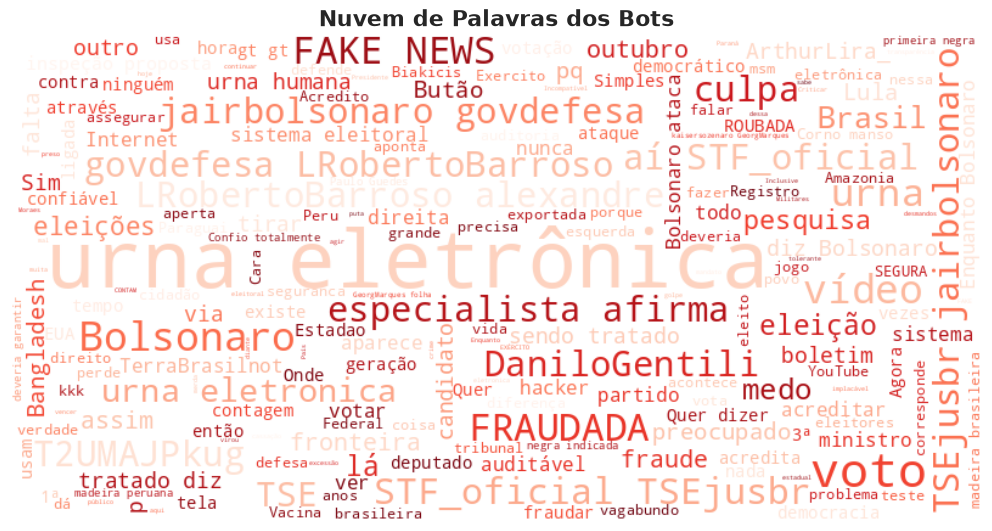

In [11]:
nltk.download("stopwords")
stop_words = set(stopwords.words("portuguese"))
stop_words.update(
    [
        "https",
        "tá",
        "né",
        "pra",
        "pro",
        "sobre",
        "mais",
        "vai",
        "com",
        "uma",
        "por",
        "q",
        "t",
        "co",
        "vc",
        "pode"
    ]
)

texto_bots = " ".join(review for review in df_bots["full_text"].dropna())
wc_bots = WordCloud(
    stopwords=stop_words,
    background_color="white",
    width=800,
    height=400,
    colormap="Reds_r",
).generate(texto_bots)

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 2)
plt.imshow(wc_bots, interpolation="bilinear")
plt.title("Nuvem de Palavras dos Bots", fontsize=16, fontweight="bold")
plt.axis("off")

plt.tight_layout()
plt.show()

O gráfico expõe o "DNA de fábrica" do robô. As palavras mais gigantescas são "FAKE NEWS", "FRAUDADA" e "Bolsonaro".
Saltam aos olhos os termos exatos do spam coordenado: "DaniloGentili", "vídeo", "culpa", além das arrobas institucionais metralhadas em massa: "STF_oficial", "jairbolsonaro", "govdefesa", "LRobertoBarroso".

Os bots operam como uma metralhadora de engenharia social. Eles não querem debater; eles usam termos de forte apelo emocional ("FAKE NEWS", "FRAUDADA") colados a nomes de entretenimento ("DaniloGentili") para criar um conteúdo altamente compartilhável que empurre a massa orgânica a inflar a nuvem.

## Por que isso importa?

O impacto real de um robô raramente está nos tweets que ele publica, mas sim na massa de manobra invisível:

1. Um influenciador grande ou um Bot lança uma mentira ou uma hashtag.

2. Perfis orquestrados começam a dar milhares de Retweets e curtidas nessa postagem em poucos minutos.

3. O algoritmo do Twitter vê aquele pico de atividade artificial e joga nos "Assuntos do Momento" (Trending Topics) ou na aba de recomendações de milhares de usuários Orgânicos.

4. O usuário orgânico (humano) vê aquilo, fica indignado e decide escrever um tweet próprio reclamando da urna.

5. Palavras-chaves, temas e perfis citados ganham visibilidade.

Em resumo: o bot não precisa escrever 1 milhão de tweets. Ele só precisa "induzir" o algoritmo a espalhar a pauta para que os usuários orgânicos façam o trabalho sujo de tuitar e inflar a base!

## Raio-X dos Bots

In [12]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_campos_principais = df_bots[['user_followers_count', 'user_friends_count', 'user_listed_count', 'user_favourites_count', 'user_statuses_count', 'dias_ativos', 'tweets_por_dia', 'engajamento', 'follow_back']]
df_campos_principais.describe()

,user_followers_count,user_friends_count,user_listed_count,user_favourites_count,user_statuses_count,dias_ativos,tweets_por_dia,engajamento,follow_back
count,190.00,190.00,190.00,190.00,190.00,190.00,190.00,190.00,190.00
mean,13885.10,9406.76,71.88,194087.41,417459.51,2082.54,187.30,0.03,150.36
std,23284.13,13427.21,245.70,168019.99,447254.08,1675.78,97.35,0.09,2005.85
min,14.00,0.00,0.00,6.00,3972.00,23.00,100.32,0.00,0.07
25%,1286.00,1446.25,0.00,57544.75,108117.25,799.00,115.52,0.00,0.87
50%,4037.00,4568.00,3.00,161758.00,266599.50,1324.00,152.29,0.01,1.07
75%,13057.50,8582.00,58.75,294827.00,551515.00,3547.00,217.38,0.02,1.50
max,98490.00,54016.00,2058.00,1089964.00,2762625.00,5676.00,598.62,0.76,27651.00


### Redes Antissociais

O maior indício de comportamento artificial ou de "bolha" pode ser obtido das medidas estatísticas de resumo:

* A mediana (50%) de retweets recebidos por eles é 0.

* A mediana de curtidas (tweet_favorites) recebidas é 1.

Embora essas contas façam um barulho enorme em volume (postando mais de 100 ou 200 vezes por dia), quase ninguém interage com elas. 

É o que mostra também a coluna "engajamento", obtida por meio de cálculo: (retweets + tweet_favorites) / tweets_por_dia

O grupo de bots possui uma atividade inversamente proporcional ao seu impacto social real. Eles apenas tentam pautar o algoritmo por repetição exaustiva, agindo como "panfleteiros digitais".